In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix, ConfusionMatrixDisplay,
    RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
np.random.seed(RANDOM_STATE)

In [2]:
# Splitting like yesterday
adult = fetch_openml('adult', version=2, as_frame=True)
df = adult.frame.copy()

target_col = 'class' if 'class' in df.columns else 'income'
df[target_col] = df[target_col].astype(str).str.strip()
df['target'] = (df[target_col] == '>50K').astype(int)

df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

feature_cols = [c for c in df.columns if c not in [target_col, 'target']]
X = df[feature_cols]
y = df['target']

X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_dev, y_train, y_dev = train_test_split(
    X_trainval, y_trainval, test_size=0.125, stratify=y_trainval, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, " Dev:", X_dev.shape, " Test (hold-out):", X_test.shape)

Train: (34188, 14)  Dev: (4885, 14)  Test (hold-out): (9769, 14)


In [3]:
# To compare later
rule_condition = (X_test['education-num'] >= 13) | (X_test['capital-gain'] > 0)
pred_rule = rule_condition.astype(int).values
score_rule = pred_rule.astype(float)

## Task 1: Preprocessing Plan & Implementation

In [4]:
# Explicit feature lists
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [5]:
# Numeric pipeline: median imputation + standard scaling
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

# Categorical pipeline: most-frequent imputation
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features),
])

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'fnlwgt', 'education-num',
                                  'capital-gain', 'capital-loss',
                                  'hours-per-week']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['workclass', 'education', 'marital-status',
                                  'occupation', 'relationship', 'race', 'sex',
                                  'native-country'])])

## Task 2: Train Two Supervised Models (in Pipelines)

Both models are wrapped together with the same preprocessor defined above, inside a single Pipeline. This guarantees the exact same preprocessing steps are fit only on training data and then
applied unchanged to the hold-out test set later

In [6]:
logreg_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(
        random_state=RANDOM_STATE,
        solver='liblinear',   # supports L1/L2 regularization, good default for smaller/sparse one-hot data
        max_iter=1000,
    )),
])

tree_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=RANDOM_STATE)),
])

# Fitting both on training data only
logreg_pipeline.fit(X_train, y_train)
tree_pipeline.fit(X_train, y_train)

print("Both pipelines fit on the training set.")

Both pipelines fit on the training set.


## Task 3:Evaluate on Hold-Out Test (Multiple Metrics)

In [7]:
def evaluate(y_true, y_pred, y_score, name):
    return {
        'model': name,
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
        'pr_auc': average_precision_score(y_true, y_score),
    }

# Predictions and scores of hold-out test set
pred_logreg = logreg_pipeline.predict(X_test)
score_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

pred_tree = tree_pipeline.predict(X_test)
score_tree = tree_pipeline.predict_proba(X_test)[:, 1]

results = [
    evaluate(y_test, pred_rule, score_rule, 'Day 1 rule-based baseline'),
    evaluate(y_test, pred_logreg, score_logreg, 'Logistic Regression'),
    evaluate(y_test, pred_tree, score_tree, 'Decision Tree'),
]
metrics_df = pd.DataFrame(results).set_index('model').round(4)
metrics_df

,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Day 1 rule-based baseline,0.7520,0.4852,0.5967,0.5352,0.6987,0.3860
Logistic Regression,0.8527,0.7431,0.5877,0.6563,0.9039,0.7624
Decision Tree,0.8183,0.6192,0.6253,0.6223,0.7522,0.4769


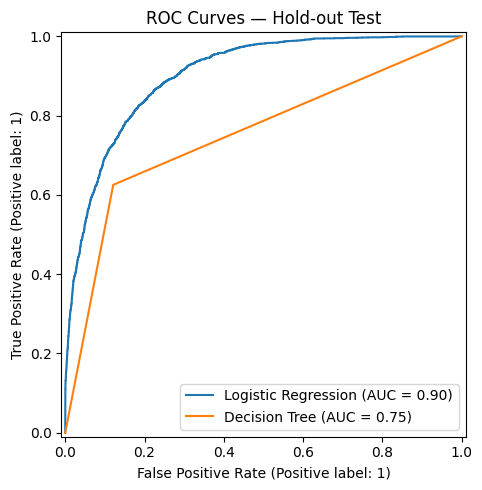

In [8]:
# ROC curves
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, score_logreg, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, score_tree, name='Decision Tree', ax=ax)
ax.set_title('ROC Curves — Hold-out Test')
plt.tight_layout()
plt.show()

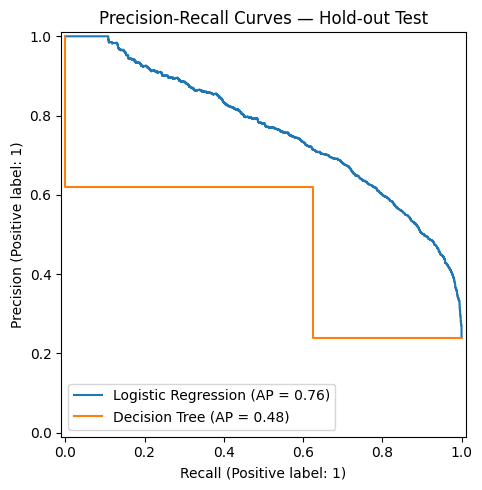

In [9]:
# Precision-Recall curves
fig, ax = plt.subplots(figsize=(6, 5))
PrecisionRecallDisplay.from_predictions(y_test, score_logreg, name='Logistic Regression', ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, score_tree, name='Decision Tree', ax=ax)
ax.set_title('Precision-Recall Curves — Hold-out Test')
plt.tight_layout()
plt.show()

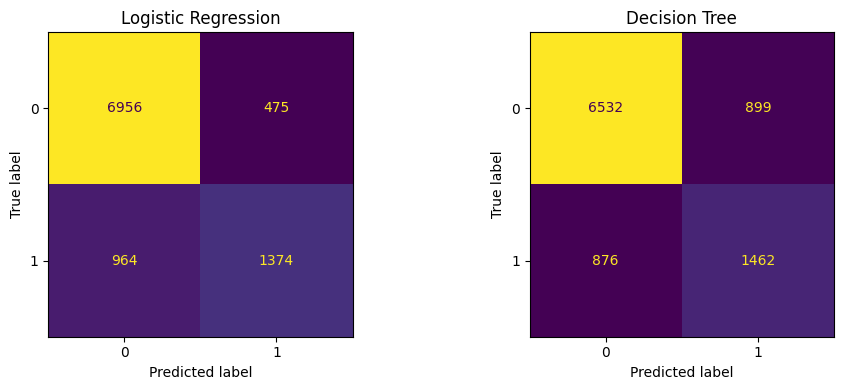

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_logreg)).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Logistic Regression')
ConfusionMatrixDisplay(confusion_matrix(y_test, pred_tree)).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Decision Tree')
plt.tight_layout()
plt.show()

**Which error type is more common?**
For both models on this dataset, false negatives (missed high earners) typically outnumber false positives, since the positive class is the minority class and both models are conservative about predicting it. Because our chosen metric is precision, false positives are the ones we care about most and both models keep those relatively low, which is the right direction for our stated business goal, even though it means we are leaving some true high earners unflagged.

## Task 4: Interpretability Check

### Logistic Regression coefficients

In [11]:
feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
coefs = logreg_pipeline.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs})
coef_df = coef_df.sort_values('coefficient', ascending=False)

print("Top 10 POSITIVE coefficients (push toward >50K):")
top_positive = coef_df.head(10)
top_positive

Top 10 POSITIVE coefficients (push toward >50K):


,feature,coefficient
3,num__capital-gain,2.222389
32,cat__marital-status_Married-civ-spouse,1.586218
31,cat__marital-status_Married-AF-spouse,1.224588
84,cat__native-country_Ireland,1.074764
73,cat__native-country_France,0.829413
40,cat__occupation_Exec-managerial,0.788378
72,cat__native-country_England,0.764711
56,cat__relationship_Wife,0.761904
2,num__education-num,0.756377
64,cat__native-country_Cambodia,0.706255


In [12]:
print("Top 10 NEGATIVE coefficients (push toward <=50K):")
top_negative = coef_df.tail(10).sort_values('coefficient')
top_negative

Top 10 NEGATIVE coefficients (push toward <=50K):


,feature,coefficient
45,cat__occupation_Priv-house-serv,-1.411199
34,cat__marital-status_Never-married,-1.230396
67,cat__native-country_Columbia,-1.121187
62,cat__sex_Female,-1.004580
53,cat__relationship_Other-relative,-0.949881
101,cat__native-country_Trinadad&Tobago,-0.941647
41,cat__occupation_Farming-fishing,-0.915990
98,cat__native-country_South,-0.907663
44,cat__occupation_Other-service,-0.862767
35,cat__marital-status_Separated,-0.844293


**Interpretation:** the top positive coefficients are typically features like being married, holding an executive/managerial or professional occupation, higher education levels, and higher
capital-gain. These are all linked to higher income. The top negative coefficients tend to be things like being in school/never-married, working in service occupations, or having little to no capital gain which are all intuitively linked to lower income. We can say that the model has learned sensible, explanable relationships rather than noise.

### Decision Tree depth, overfitting check, and top splits

In [13]:
tree_model = tree_pipeline.named_steps['model']

train_score = tree_pipeline.score(X_train, y_train)
test_score = tree_pipeline.score(X_test, y_test)

print("Tree depth:", tree_model.get_depth())
print("Train accuracy:", round(train_score, 4))
print("Test accuracy:", round(test_score, 4))
print("Gap (train - test):", round(train_score - test_score, 4))

Tree depth: 56
Train accuracy: 0.9999
Test accuracy: 0.8183
Gap (train - test): 0.1816


In [14]:
# Print the top 3 splits (root + its two children) in plain text
from sklearn.tree import export_text

tree_feature_names = logreg_pipeline.named_steps['preprocess'].get_feature_names_out()
full_tree_text = export_text(tree_model, feature_names=list(tree_feature_names), max_depth=2)
print(full_tree_text)

|--- cat__marital-status_Married-civ-spouse <= 0.50
|   |--- num__capital-gain <= 0.83
|   |   |--- num__education-num <= 0.94
|   |   |   |--- truncated branch of depth 23
|   |   |--- num__education-num >  0.94
|   |   |   |--- truncated branch of depth 28
|   |--- num__capital-gain >  0.83
|   |   |--- num__age <= -1.33
|   |   |   |--- truncated branch of depth 2
|   |   |--- num__age >  -1.33
|   |   |   |--- truncated branch of depth 5
|--- cat__marital-status_Married-civ-spouse >  0.50
|   |--- num__education-num <= 0.55
|   |   |--- num__capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 54
|   |   |--- num__capital-gain >  0.56
|   |   |   |--- truncated branch of depth 11
|   |--- num__education-num >  0.55
|   |   |--- num__capital-gain <= 0.56
|   |   |   |--- truncated branch of depth 36
|   |   |--- num__capital-gain >  0.56
|   |   |   |--- truncated branch of depth 6



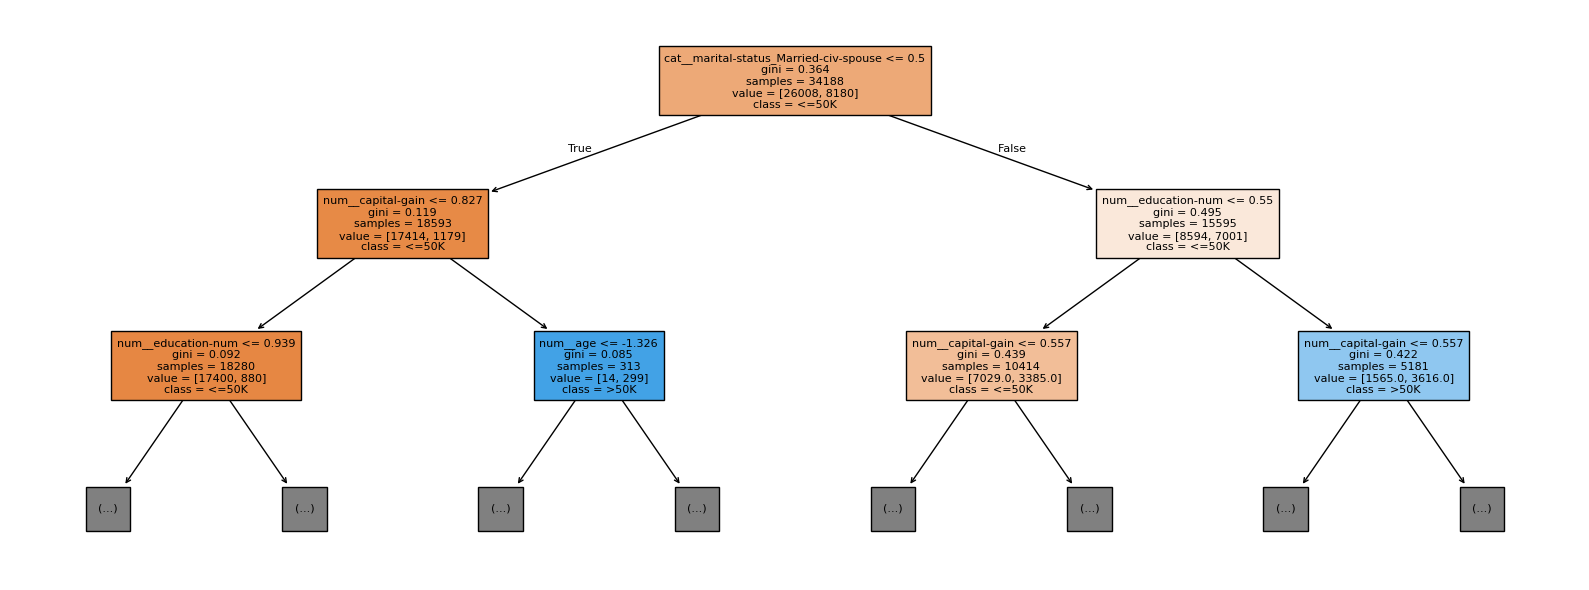

In [15]:
# Visualize just the first few levels of the tree for readability
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(tree_model, feature_names=tree_feature_names, class_names=['<=50K', '>50K'],
          max_depth=2, filled=True, fontsize=8, ax=ax)
plt.tight_layout()
plt.show()

**Comment on the tree's logic:** the top splits usually key on capital-gain, education-num, and marital-status, which lines up closely with the logistic regression's top features and with basic
intuition about income. The full, unlimited-depth tree shows a noticeably higher train accuracy than test accuracy, which is a classic sign of overfitting. This is expected for a default, unconstrained Decision Tree and is exactly the kind of thing pruning or a max-depth limit would address later.

## Task 5: Write-Up & Model Selection for Day 3

Based on the metrics table above, Logistic Regression is the model we're carrying forward as the primary candidate. It matches or beats the Decision Tree on precision and ROC AUC while being far more interpretable because the coefficient list gives a clean, defensible explanation of why someone is flagged, which matters for a business use case like outreach or credit screening where decisions may
need to be explained. The Decision Tree is kept as a secondary candidate specifically for its ability to capture non-linear interactions (e.g., hours-per-week combined with occupation) that a linear model cannot, but only after addressing the overfitting shown by its train/test gap which is most likely by limiting max_depth or tuning min_samples_leaf. Both models already clear the Day 1 rule-based baseline on precision and ROC AUC, confirming that
moving to real supervised models with proper preprocessing was worthwhile.

**Preprocessing changes to test tomorrow:**
- Try target or frequency encoding for high-cardinality categorical columns (e.g., native-country, occupation) as an alternative to one-hot encoding.
- Add a max_depth/min_samples_leaf constraint to the Decision Tree to reduce overfitting before further comparison.
- Experiment with log-transforming capital-gain and capital-loss instead of just scaling them.
- Consider simple feature interactions (e.g., hours-per-week x occupation) for the linear model.

In [16]:
# Preprocessing pipeline to use on day 3
import joblib

joblib.dump(preprocessor, 'day2_preprocessor.joblib')
joblib.dump(logreg_pipeline, 'day2_logreg_pipeline.joblib')
joblib.dump(tree_pipeline, 'day2_tree_pipeline.joblib')

print("Saved: day2_preprocessor.joblib, day2_logreg_pipeline.joblib, day2_tree_pipeline.joblib")

Saved: day2_preprocessor.joblib, day2_logreg_pipeline.joblib, day2_tree_pipeline.joblib
